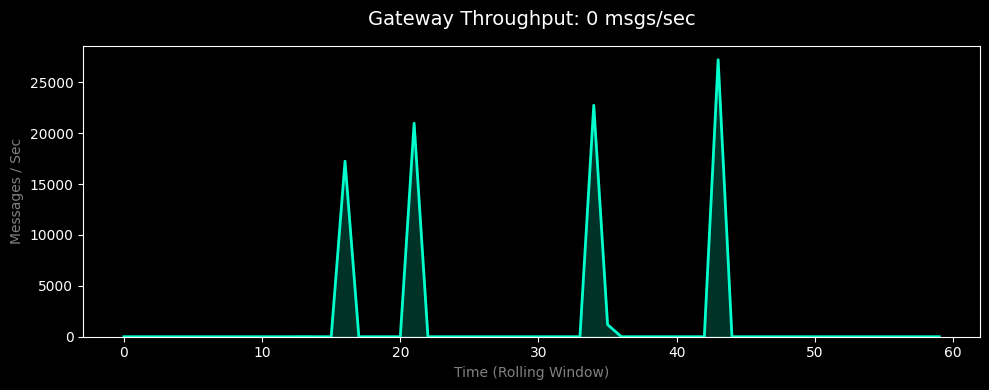

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
from collections import deque
from fabrictestbed_extensions.fablib.fablib import FablibManager as fablib_manager

fablib = fablib_manager(project_id="f5b4fc7d-978f-45be-9530-b38db8ef5046")
slice_name = 'prediction_market_project_4-20-26'
slice = fablib.get_slice(slice_name)
gateway = slice.get_node(name="gateway")
file_path = "/home/ubuntu/PredictionMarketMatchingEngine/metrics.txt"

plt.style.use('dark_background')

window_size = 60
time_data = list(range(window_size))
throughput_data = deque([0]*window_size, maxlen=window_size)

print("Starting Dashboard...")
time.sleep(2)

try:
    while True:
        try:
            stdout, stderr = gateway.execute(f"cat {file_path}", quiet=True)
            raw_text = stdout.strip()
            current_throughput = int(raw_text) if raw_text else 0
        except Exception:
            current_throughput = 0
            
        throughput_data.append(current_throughput)
        
        # clear the cell output
        clear_output(wait=True)
        
        # 3. build plt
        fig, ax = plt.subplots(figsize=(10, 4))
        
        # plot the line
        ax.plot(time_data, list(throughput_data), color='#00ffcc', linewidth=2)
        ax.fill_between(time_data, list(throughput_data), color='#00ffcc', alpha=0.2)
        
        # formatting
        ax.set_title(f"Gateway Throughput: {current_throughput} msgs/sec", fontsize=14, pad=15)
        ax.set_xlabel("Time (Rolling Window)", color='gray')
        ax.set_ylabel("Messages / Sec", color='gray')
        ax.set_ylim(bottom=0) # Keep the bottom of the graph at 0
        
        plt.tight_layout()
        plt.show()
        plt.close(fig) 
        
        # wait before polling again
        time.sleep(0.1)
        
except KeyboardInterrupt:
    clear_output(wait=True)
    print("Dashboard stopped successfully.")